# Tag 04 - Outlier Detection with Own Pharma Data

This notebook applies Day 4 anomaly/outlier detection methods to an own dataset:

`indian_pharmaceutical_products_clean.csv`

## Context

The dataset contains pharmaceutical products.  
The goal is to detect unusual products, for example:

- unusually high or low prices
- rare manufacturers
- rare compositions
- products with unusual numerical patterns
- products that several models classify as anomalies

## Methods

1. Data understanding
2. Preprocessing
3. Feature engineering
4. IQR method
5. Isolation Forest
6. Local Outlier Factor - LOF
7. ABOD
8. CBLOF
9. Method agreement
10. Business interpretation for Pharma context

## Dataset Validation
Run this cell to verify that your datasets are present and correctly formatted.

In [1]:
# --- DATASET VALIDATION ---
import os
import pandas as pd

def validate_dataset(filepath, expected_columns=None, avoid_columns=None):
    if not os.path.exists(filepath):
        print(f'❌ ERROR: Dataset not found at {filepath}')
        return False
    try:
        df = pd.read_csv(filepath, nrows=5)
        print(f'✅ SUCCESS: Dataset found at {filepath} (Columns: {df.shape[1]})')
        if expected_columns:
            missing = [c for c in expected_columns if c not in df.columns]
            if missing:
                print(f'⚠️ WARNING: Missing expected columns: {missing}')
                return False
        if avoid_columns:
            forbidden = [c for c in avoid_columns if c in df.columns]
            if forbidden:
                print(f'❌ ERROR: Found forbidden columns {forbidden}. Wrong dataset!')
                return False
        return True
    except Exception as e:
        print(f'❌ ERROR: Could not read dataset: {e}')
        return False

print('Validation helper loaded. Call validate_dataset(path) before loading your data.')
# validate_dataset('../data/your_dataset.csv')

Validation helper loaded. Call validate_dataset(path) before loading your data.


In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from pyod.models.abod import ABOD
from pyod.models.cblof import CBLOF
from pyod.models.iforest import IForest

In [3]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"

OUTPUT_DIR.mkdir(exist_ok=True)

data_path = DATA_DIR / "indian_pharmaceutical_products_clean.csv"

if not data_path.exists():
    raise FileNotFoundError(
        "Dataset not found. Please put indian_pharmaceutical_products_clean.csv into:\n"
        f"{DATA_DIR}"
    )

print("Using dataset:", data_path)
print("Output folder:", OUTPUT_DIR)

Using dataset: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\anomaly-detection-outlier-analysis\data\indian_pharmaceutical_products_clean.csv
Output folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\anomaly-detection-outlier-analysis\output


In [4]:
def save_plot(filename):
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)

def clean_column_name(col):
    col = str(col).strip().lower()
    col = re.sub(r"[^a-zA-Z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col)
    return col.strip("_")

def parse_numeric_value(x):
    if pd.isna(x):
        return np.nan
    
    text = str(x)
    text = text.replace(",", "")
    text = re.sub(r"[^0-9.\-]", "", text)
    
    if text in ["", ".", "-", "-."]:
        return np.nan
    
    try:
        return float(text)
    except:
        return np.nan

# 1. Load the dataset

We first load the Pharma dataset and inspect:

- number of rows and columns
- column names
- data types
- missing values
- first rows

This step is important because real datasets are often messy.

In [5]:
try:
    df = pd.read_csv(data_path)
except UnicodeDecodeError:
    df = pd.read_csv(data_path, encoding="latin1")

print("Original shape:", df.shape)
display(df.head())
display(df.info())

Original shape: (253973, 15)


,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,False,tablet,10.0,strip,2,Amoxycillin,500mg,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",antibiotic,strip of 10 tablets,Glaxo SmithKline Pharmaceuticals Ltd
1,2,Azithral 500 Tablet,Alembic Pharmaceuticals Ltd,132.36,False,tablet,5.0,strip,1,Azithromycin,500mg,"[{'name': 'Azithromycin', 'strength': '500mg',...",antibiotic,strip of 5 tablets,Alembic Pharmaceuticals Ltd
2,3,Ascoril LS Syrup,Glenmark Pharmaceuticals Ltd,118.00,False,syrup,100.0,bottle,2,Ambroxol,30mg/5ml,"[{'name': 'Ambroxol', 'strength': '30mg/5ml', ...",bronchodilator,bottle of 100 ml Syrup,Glenmark Pharmaceuticals Ltd
3,4,Allegra 120mg Tablet,Sanofi India Ltd,218.81,False,tablet,10.0,strip,1,Fexofenadine,120mg,"[{'name': 'Fexofenadine', 'strength': '120mg',...",antihistamine,strip of 10 tablets,Sanofi India Ltd
4,5,Avil 25 Tablet,Sanofi India Ltd,10.96,False,tablet,15.0,strip,1,Pheniramine,25mg,"[{'name': 'Pheniramine', 'strength': '25mg', '...",other,strip of 15 tablets,Sanofi India Ltd


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253973 entries, 0 to 253972
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   product_id              253973 non-null  int64  
 1   brand_name              253973 non-null  object 
 2   manufacturer            253973 non-null  object 
 3   price_inr               253973 non-null  float64
 4   is_discontinued         253973 non-null  bool   
 5   dosage_form             253973 non-null  object 
 6   pack_size               231643 non-null  float64
 7   pack_unit               231643 non-null  object 
 8   num_active_ingredients  253973 non-null  int64  
 9   primary_ingredient      253973 non-null  object 
 10  primary_strength        228775 non-null  object 
 11  active_ingredients      253973 non-null  object 
 12  therapeutic_class       253973 non-null  object 
 13  packaging_raw           253973 non-null  object 
 14  manufacturer_raw    

None

In [6]:
# Clean column names

df.columns = [clean_column_name(c) for c in df.columns]

print("Cleaned columns:")
print(df.columns.tolist())

display(df.head())

Cleaned columns:
['product_id', 'brand_name', 'manufacturer', 'price_inr', 'is_discontinued', 'dosage_form', 'pack_size', 'pack_unit', 'num_active_ingredients', 'primary_ingredient', 'primary_strength', 'active_ingredients', 'therapeutic_class', 'packaging_raw', 'manufacturer_raw']


,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,False,tablet,10.0,strip,2,Amoxycillin,500mg,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",antibiotic,strip of 10 tablets,Glaxo SmithKline Pharmaceuticals Ltd
1,2,Azithral 500 Tablet,Alembic Pharmaceuticals Ltd,132.36,False,tablet,5.0,strip,1,Azithromycin,500mg,"[{'name': 'Azithromycin', 'strength': '500mg',...",antibiotic,strip of 5 tablets,Alembic Pharmaceuticals Ltd
2,3,Ascoril LS Syrup,Glenmark Pharmaceuticals Ltd,118.00,False,syrup,100.0,bottle,2,Ambroxol,30mg/5ml,"[{'name': 'Ambroxol', 'strength': '30mg/5ml', ...",bronchodilator,bottle of 100 ml Syrup,Glenmark Pharmaceuticals Ltd
3,4,Allegra 120mg Tablet,Sanofi India Ltd,218.81,False,tablet,10.0,strip,1,Fexofenadine,120mg,"[{'name': 'Fexofenadine', 'strength': '120mg',...",antihistamine,strip of 10 tablets,Sanofi India Ltd
4,5,Avil 25 Tablet,Sanofi India Ltd,10.96,False,tablet,15.0,strip,1,Pheniramine,25mg,"[{'name': 'Pheniramine', 'strength': '25mg', '...",other,strip of 15 tablets,Sanofi India Ltd


In [7]:
# Missing values overview

missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_table.head(30))

missing_table.to_csv(OUTPUT_DIR / "day04_pharma_missing_values.csv")

,missing_count,missing_percent
primary_strength,25198,9.921527
pack_size,22330,8.792273
pack_unit,22330,8.792273
product_id,0,0.000000
brand_name,0,0.000000
manufacturer,0,0.000000
price_inr,0,0.000000
is_discontinued,0,0.000000
dosage_form,0,0.000000
num_active_ingredients,0,0.000000


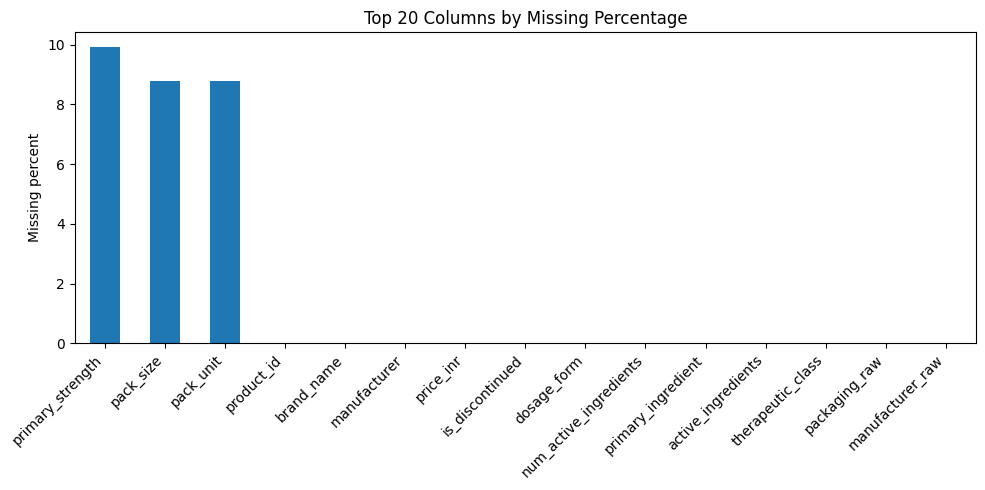

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\anomaly-detection-outlier-analysis\output\day04_pharma_missing_values_top20.png


In [8]:
plt.figure(figsize=(10, 5))
missing_table.head(20)["missing_percent"].plot(kind="bar")
plt.title("Top 20 Columns by Missing Percentage")
plt.ylabel("Missing percent")
plt.xticks(rotation=45, ha="right")
save_plot("day04_pharma_missing_values_top20.png")

# 2. Detect useful columns

For outlier detection, we need numerical features.

In Pharma data, useful numerical information may be hidden in text columns, for example:

- price
- mrp
- cost
- quantity
- dosage
- package size

Therefore, we try to convert potentially numeric text columns into numeric values.

In [9]:
df_work = df.copy()

# Try to parse numeric values from object columns that look like price, amount, quantity, dosage, or size

numeric_hint_words = [
    "price", "mrp", "cost", "amount", "rate", "value",
    "qty", "quantity", "size", "dosage", "dose", "strength"
]

created_numeric_cols = []

for col in df_work.columns:
    if df_work[col].dtype == "object":
        if any(word in col for word in numeric_hint_words):
            new_col = col + "_numeric"
            df_work[new_col] = df_work[col].apply(parse_numeric_value)
            
            # Keep only if enough values were successfully parsed
            valid_ratio = df_work[new_col].notna().mean()
            if valid_ratio >= 0.05:
                created_numeric_cols.append(new_col)
            else:
                df_work.drop(columns=[new_col], inplace=True)

print("Created numeric columns:")
print(created_numeric_cols)

Created numeric columns:
['primary_strength_numeric']


In [10]:
# Identify existing numeric columns

numeric_cols = df_work.select_dtypes(include=[np.number]).columns.tolist()

# Remove columns that are likely IDs if they have too many unique values and no numerical meaning
id_like_cols = [c for c in numeric_cols if "id" in c and df_work[c].nunique() > 1000]
numeric_cols = [c for c in numeric_cols if c not in id_like_cols]

print("Numeric columns used:")
print(numeric_cols)

Numeric columns used:
['price_inr', 'pack_size', 'num_active_ingredients', 'primary_strength_numeric']


# 3. Feature engineering from categorical/text columns

Many Pharma columns are categorical/text:

- product name
- manufacturer
- composition
- category
- pack size

Outlier detection models need numbers.  
So we create simple numerical features from text columns:

1. text length
2. number of words
3. frequency encoding

Frequency encoding means:

A rare manufacturer or rare composition gets a low frequency value.  
This is useful because very rare categories may be suspicious or at least unusual.

In [11]:
object_cols = df_work.select_dtypes(include=["object"]).columns.tolist()

# Limit number of text columns to keep the notebook efficient
object_cols_for_features = object_cols[:8]

print("Object columns used for feature engineering:")
print(object_cols_for_features)

feature_parts = []

# Numeric features
if len(numeric_cols) > 0:
    feature_parts.append(df_work[numeric_cols].copy())

# Text-derived features
text_feature_df = pd.DataFrame(index=df_work.index)

for col in object_cols_for_features:
    text_data = df_work[col].fillna("").astype(str)
    
    text_feature_df[col + "_text_length"] = text_data.str.len()
    text_feature_df[col + "_word_count"] = text_data.str.split().str.len()
    
    freq = text_data.value_counts(normalize=True)
    text_feature_df[col + "_frequency"] = text_data.map(freq)

feature_parts.append(text_feature_df)

features_df = pd.concat(feature_parts, axis=1)

# Replace inf and missing values
features_df = features_df.replace([np.inf, -np.inf], np.nan)
features_df = features_df.fillna(features_df.median(numeric_only=True))
features_df = features_df.fillna(0)

print("Feature matrix shape:", features_df.shape)
display(features_df.head())

features_df.to_csv(OUTPUT_DIR / "day04_pharma_engineered_features.csv", index=False)

Object columns used for feature engineering:
['brand_name', 'manufacturer', 'dosage_form', 'pack_unit', 'primary_ingredient', 'primary_strength', 'active_ingredients', 'therapeutic_class']


Feature matrix shape: (253973, 28)


,price_inr,pack_size,num_active_ingredients,primary_strength_numeric,brand_name_text_length,brand_name_word_count,brand_name_frequency,manufacturer_text_length,manufacturer_word_count,manufacturer_frequency,...,primary_ingredient_frequency,primary_strength_text_length,primary_strength_word_count,primary_strength_frequency,active_ingredients_text_length,active_ingredients_word_count,active_ingredients_frequency,therapeutic_class_text_length,therapeutic_class_word_count,therapeutic_class_frequency
0,223.42,10.0,2,500.0,24,4,0.000004,36,4,0.001551,...,0.033665,5,1,0.076532,187,16,0.008221,10,1,0.120721
1,132.36,5.0,1,500.0,19,3,0.000004,27,3,0.003304,...,0.019132,5,1,0.076532,91,7,0.007863,10,1,0.120721
2,118.00,100.0,2,305.0,16,3,0.000004,28,3,0.004453,...,0.009387,8,1,0.001910,188,14,0.001347,14,1,0.007095
3,218.81,10.0,1,120.0,20,3,0.000008,16,3,0.001382,...,0.003020,5,1,0.003768,91,7,0.001445,13,1,0.052817
4,10.96,15.0,1,25.0,14,3,0.000004,16,3,0.001382,...,0.000063,4,1,0.015301,87,7,0.000012,5,1,0.567458


In [12]:
# If the dataset is very large, we use a sample for computationally heavier algorithms.

MAX_ROWS = 12000

if len(features_df) > MAX_ROWS:
    sample_df = features_df.sample(n=MAX_ROWS, random_state=42)
    df_sample_original = df_work.loc[sample_df.index].copy()
else:
    sample_df = features_df.copy()
    df_sample_original = df_work.copy()

print("Rows used for modeling:", sample_df.shape[0])
print("Features used for modeling:", sample_df.shape[1])

Rows used for modeling: 12000
Features used for modeling: 28


# 4. Scaling

Distance-based and geometry-based methods need scaling.

Why?

- LOF uses distances to neighbors.
- ABOD uses angle relationships.
- CBLOF uses clustering distances.
- Isolation Forest is less sensitive, but scaling still helps comparison.

We use StandardScaler:

z = (x - mean) / standard deviation

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(sample_df)

print("Scaled matrix shape:", X_scaled.shape)

Scaled matrix shape: (12000, 28)


# 5. IQR Method

The IQR method is a simple statistical method for numerical outlier detection.

Formula:

IQR = Q3 - Q1

Lower bound:

Q1 - 1.5 * IQR

Upper bound:

Q3 + 1.5 * IQR

If a value is outside this range, it can be considered an outlier.

This method is simple but only checks columns separately.

In [14]:
def iqr_detection(dataframe, factor=1.5):
    mask = np.zeros(len(dataframe), dtype=bool)
    bounds = {}

    for col in dataframe.columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        
        bounds[col] = {
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower_Bound": lower,
            "Upper_Bound": upper
        }
        
        mask = mask | (dataframe[col] < lower) | (dataframe[col] > upper)

    return mask.astype(int), pd.DataFrame(bounds).T

y_iqr, iqr_bounds = iqr_detection(sample_df)

print("IQR outliers:", y_iqr.sum())
display(iqr_bounds.head(20))

iqr_bounds.to_csv(OUTPUT_DIR / "day04_pharma_iqr_bounds.csv")

IQR outliers: 7817


,Q1,Q3,IQR,Lower_Bound,Upper_Bound
price_inr,48.000000,140.000000,92.000000,-90.000000,278.000000
pack_size,10.000000,10.000000,0.000000,10.000000,10.000000
num_active_ingredients,1.000000,2.000000,1.000000,-0.500000,3.500000
primary_strength_numeric,20.000000,200.000000,180.000000,-250.000000,470.000000
brand_name_text_length,18.000000,25.000000,7.000000,7.500000,35.500000
brand_name_word_count,3.000000,4.000000,1.000000,1.500000,5.500000
brand_name_frequency,0.000004,0.000004,0.000000,0.000004,0.000004
manufacturer_text_length,17.000000,27.000000,10.000000,2.000000,42.000000
manufacturer_word_count,2.000000,4.000000,2.000000,-1.000000,7.000000
manufacturer_frequency,0.000161,0.000878,0.000717,-0.000913,0.001953


# 6. Isolation Forest

Isolation Forest tries to isolate points using random splits.

Core idea:

Outliers are easier to isolate than normal points.

If a product can be isolated with only a few random splits, it may be unusual.

In [15]:
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

iso_raw = iso_model.fit_predict(X_scaled)

# sklearn: -1 = outlier, 1 = normal
y_iso = np.where(iso_raw == -1, 1, 0)

print("Isolation Forest outliers:", y_iso.sum())

Isolation Forest outliers: 360


# 7. LOF - Local Outlier Factor

LOF compares the local density of a point with the density of its neighbors.

A product is suspicious if it is much less dense than similar nearby products.

Important:

LOF values are not direct probabilities.
The same LOF score can mean different things in different datasets.

In [16]:
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.03
)

lof_raw = lof_model.fit_predict(X_scaled)

# sklearn: -1 = outlier, 1 = normal
y_lof = np.where(lof_raw == -1, 1, 0)

print("LOF outliers:", y_lof.sum())

  File "C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\esmae\.conda\envs\py311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\esmae\.conda\envs\py311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\esmae\.conda\envs\py311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


LOF outliers: 360


# 8. ABOD - Angle-Based Outlier Detection

ABOD uses angles between points instead of only distances.

Why this is useful:

In high-dimensional data, distances can become less informative.
Angles can sometimes capture geometric relationships better.

We use FastABOD from PyOD.

In [17]:
# ABOD can be slow, therefore we use the already sampled data.

abod_model = ABOD(
    contamination=0.03,
    method="fast",
    n_neighbors=20
)

abod_model.fit(X_scaled)
y_abod = abod_model.labels_

print("ABOD outliers:", y_abod.sum())

ABOD outliers: 360


# 9. CBLOF - Cluster-Based Local Outlier Factor

CBLOF uses clustering.

Core idea:

- Products are grouped into clusters.
- Products far from cluster centers or in small unusual clusters may be outliers.

In [18]:
# n_clusters must be smaller than the number of rows.
n_clusters = min(8, max(2, len(sample_df) // 1000))

cblof_model = CBLOF(
    contamination=0.03,
    n_clusters=n_clusters,
    random_state=42
)

cblof_model.fit(X_scaled)
y_cblof = cblof_model.labels_

print("CBLOF outliers:", y_cblof.sum())
print("n_clusters:", n_clusters)

CBLOF outliers: 360
n_clusters: 8


# 10. PyOD IForest

PyOD IForest has the same interface as other PyOD models.

This makes comparison easier:

- fit()
- labels_
- decision_scores_

In [19]:
pyod_iforest = IForest(
    contamination=0.03,
    random_state=42
)

pyod_iforest.fit(X_scaled)
y_pyod_iforest = pyod_iforest.labels_

print("PyOD IForest outliers:", y_pyod_iforest.sum())

PyOD IForest outliers: 360


# 11. Compare all methods

Because this real Pharma dataset has no ground truth labels for outliers, we cannot calculate real precision or recall.

Instead, we compare:

- how many outliers each method found
- where methods agree
- which products are flagged by several methods

If several methods identify the same product as an outlier, it is more suspicious.

In [20]:
result_df = df_sample_original.copy()

result_df["IQR_outlier"] = y_iqr
result_df["Isolation_Forest_outlier"] = y_iso
result_df["LOF_outlier"] = y_lof
result_df["ABOD_outlier"] = y_abod
result_df["CBLOF_outlier"] = y_cblof
result_df["PyOD_IForest_outlier"] = y_pyod_iforest

method_cols = [
    "IQR_outlier",
    "Isolation_Forest_outlier",
    "LOF_outlier",
    "ABOD_outlier",
    "CBLOF_outlier",
    "PyOD_IForest_outlier"
]

result_df["number_of_methods_flagging_outlier"] = result_df[method_cols].sum(axis=1)

method_summary = pd.DataFrame({
    "Method": method_cols,
    "Number_of_outliers": [result_df[col].sum() for col in method_cols],
    "Outlier_percent": [result_df[col].mean() * 100 for col in method_cols]
})

display(method_summary)

method_summary.to_csv(OUTPUT_DIR / "day04_pharma_method_summary.csv", index=False)
result_df.to_csv(OUTPUT_DIR / "day04_pharma_outlier_predictions.csv", index=False)

,Method,Number_of_outliers,Outlier_percent
0,IQR_outlier,7817,65.141667
1,Isolation_Forest_outlier,360,3.000000
2,LOF_outlier,360,3.000000
3,ABOD_outlier,360,3.000000
4,CBLOF_outlier,360,3.000000
5,PyOD_IForest_outlier,360,3.000000


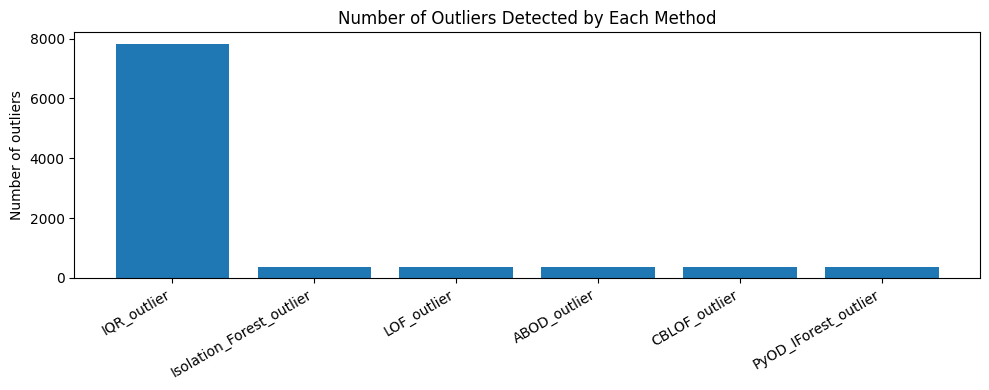

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\anomaly-detection-outlier-analysis\output\day04_pharma_outliers_by_method.png


In [21]:
plt.figure(figsize=(10, 4))
plt.bar(method_summary["Method"], method_summary["Number_of_outliers"])
plt.title("Number of Outliers Detected by Each Method")
plt.ylabel("Number of outliers")
plt.xticks(rotation=30, ha="right")
save_plot("day04_pharma_outliers_by_method.png")

number_of_methods_flagging_outlier
0    4128
1    6984
2     421
3     234
4     103
5     103
6      27
Name: count, dtype: int64

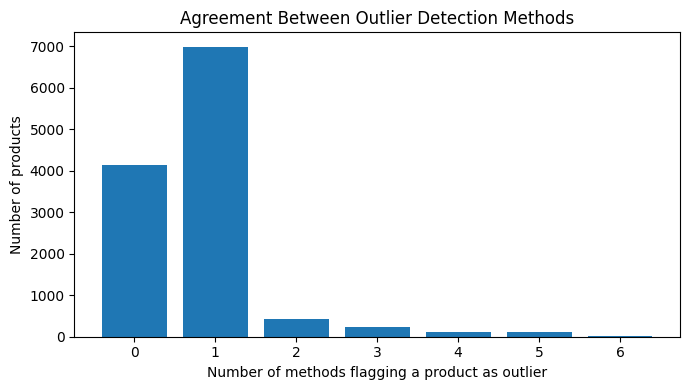

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\anomaly-detection-outlier-analysis\output\day04_pharma_method_agreement.png


In [22]:
agreement_counts = result_df["number_of_methods_flagging_outlier"].value_counts().sort_index()

display(agreement_counts)

plt.figure(figsize=(7, 4))
plt.bar(agreement_counts.index.astype(str), agreement_counts.values)
plt.title("Agreement Between Outlier Detection Methods")
plt.xlabel("Number of methods flagging a product as outlier")
plt.ylabel("Number of products")
save_plot("day04_pharma_method_agreement.png")

# 12. Top suspicious products

We now inspect products that were flagged by the largest number of methods.

These are not automatically errors.

They are candidates for manual review.

Possible business interpretations:

- unusually expensive product
- rare manufacturer
- rare composition
- unusual package size
- missing or strange metadata

In [23]:
top_suspicious = result_df.sort_values(
    "number_of_methods_flagging_outlier",
    ascending=False
).head(30)

display(top_suspicious)

top_suspicious.to_csv(OUTPUT_DIR / "day04_pharma_top_suspicious_products.csv", index=False)

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,...,packaging_raw,manufacturer_raw,primary_strength_numeric,IQR_outlier,Isolation_Forest_outlier,LOF_outlier,ABOD_outlier,CBLOF_outlier,PyOD_IForest_outlier,number_of_methods_flagging_outlier
200241,200242,Slvrgen Cream,Bharat Biotech,707.00,False,cream,30.0,tube,2,Recombinant Human Epidermal Growth Factor,...,tube of 30 gm Cream,Bharat Biotech,NaN,1,1,1,1,1,1,6
108339,108340,Iviglob EX 2.5gm Infusion,Vhb Life Sciences Inc,9990.00,False,solution,50.0,bottle,1,Human Normal Immunoglobulin,...,bottle of 50 ml Solution for Infusion,Vhb Life Sciences Inc,2.5,1,1,1,1,1,1,6
237082,237083,Volitek Advance Instant Pain Relief Spray (55g...,Meditek Lifesciences Pvt. Ltd.,300.00,False,other,NaN,NaN,1,Diclofenac,...,combo pack of 2 bottles,Meditek Lifesciences Pvt. Ltd.,NaN,1,1,1,1,1,1,6
137003,137004,Myolax Gel,Novostart Life Science,84.96,False,gel,NaN,NaN,2,Diclofenac,...,tube of 1 Gel,Novostart Life Science,NaN,1,1,1,1,1,1,6
236549,236550,Viro 4 Kit,Emcure Pharmaceuticals Ltd,828.50,False,other,NaN,NaN,2,Tenofovir disoproxil fumarate,...,packet of 1 Kit,Emcure Pharmaceuticals Ltd,300.0,1,1,1,1,1,1,6
72661,72662,Estrabet 0.06% Gel,Abbott,966.30,False,gel,80.0,tube,1,Estradiol,...,tube of 80 gm Vaginal gel,Abbott,NaN,1,1,1,1,1,1,6
161856,161857,Ostospray,Sun Pharmaceutical Industries Ltd,1385.00,False,solution,7.0,ml,1,Calcitonin,...,bottle of 3.7 ml Nasal Solution,Sun Pharmaceutical Industries Ltd,NaN,1,1,1,1,1,1,6
98277,98278,Genericart Olmesartan Medoxomil+Amlodipine+Hyd...,Swast Aushadhi Seva Generic Medicine Store,205.00,False,tablet,10.0,strip,2,Olmesartan Medoxomil,...,strip of 10 tablets,Swast Aushadhi Seva Generic Medicine Store,40.0,1,1,1,1,1,1,6
218537,218538,Trimoliv DS Oral Suspension Sugar Free,Allegiant Biotech,203.00,False,suspension,200.0,bottle,2,Silymarin,...,bottle of 200 ml Oral Suspension,Allegiant Biotech,7010.0,1,1,1,1,1,1,6
218931,218932,Trazumab 440mg Solution for Infusion,Emcure Pharmaceuticals Ltd,52584.48,False,solution,NaN,NaN,1,Trastuzumab,...,vial of 1 Solution for Infusion,Emcure Pharmaceuticals Ltd,440.0,1,1,1,1,1,1,6


# 13. Price-focused analysis

If the dataset contains price-related columns, we analyze them separately.

This is useful in Pharma data because extreme prices can indicate:

- special medication
- data entry error
- rare product
- unusually expensive manufacturer/product combination

Price-like numeric columns:
['price_inr']


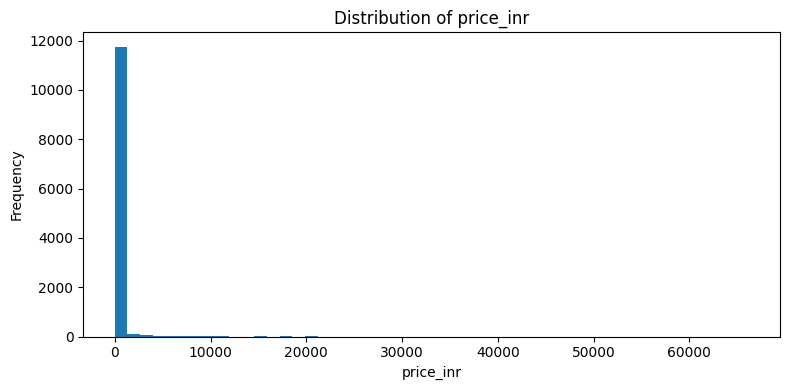

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\anomaly-detection-outlier-analysis\output\day04_pharma_distribution_price_inr.png


In [24]:
price_like_cols = [
    col for col in result_df.columns
    if any(word in col for word in ["price", "mrp", "cost", "amount", "rate"])
    and pd.api.types.is_numeric_dtype(result_df[col])
]

print("Price-like numeric columns:")
print(price_like_cols)

for col in price_like_cols[:5]:
    plt.figure(figsize=(8, 4))
    plt.hist(result_df[col].dropna(), bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    save_plot(f"day04_pharma_distribution_{col}.png")

In [25]:
# Show top values for price-like columns

for col in price_like_cols[:5]:
    print("\nTop 10 highest values for:", col)
    display(result_df.sort_values(col, ascending=False).head(10))


Top 10 highest values for: price_inr


,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,...,packaging_raw,manufacturer_raw,primary_strength_numeric,IQR_outlier,Isolation_Forest_outlier,LOF_outlier,ABOD_outlier,CBLOF_outlier,PyOD_IForest_outlier,number_of_methods_flagging_outlier
104209,104210,Herclon Injection,Roche Products India Pvt Ltd,66156.25,False,injection,NaN,NaN,1,Trastuzumab,...,vial of 1 Injection,Roche Products India Pvt Ltd,440.0,1,1,1,1,1,1,6
218931,218932,Trazumab 440mg Solution for Infusion,Emcure Pharmaceuticals Ltd,52584.48,False,solution,NaN,NaN,1,Trastuzumab,...,vial of 1 Solution for Infusion,Emcure Pharmaceuticals Ltd,440.0,1,1,1,1,1,1,6
217048,217049,Tarceva 150mg Tablet,Roche Products India Pvt Ltd,40300.00,False,tablet,10.0,strip,1,Erlotinib,...,strip of 10 tablets,Roche Products India Pvt Ltd,150.0,1,0,1,1,1,0,4
26653,26654,Bevacirel 400mg Injection,Reliance Life Sciences,38856.34,False,injection,16.0,ml,1,Bevacizumab,...,vial of 16 ml Injection,Reliance Life Sciences,400.0,1,0,1,1,1,0,4
134347,134348,Mabtas RA 500mg Injection,Intas Pharmaceuticals Ltd,37675.58,False,injection,50.0,ml,1,Rituximab,...,vial of 50 ml Injection,Intas Pharmaceuticals Ltd,500.0,1,0,1,1,1,0,4
114950,114951,Jevatax 60mg Injection,Cipla Ltd,36000.00,True,injection,NaN,NaN,1,Cabazitaxel,...,vial of 1 Injection,Cipla Ltd,60.0,1,1,1,1,1,1,6
203214,203215,Stemfor Injection,Intas Pharmaceuticals Ltd,33222.97,False,injection,2.0,ml,1,Plerixafor,...,vial of 1.2 ml Injection,Intas Pharmaceuticals Ltd,20.0,1,0,0,1,1,0,3
52983,52984,Cabocyta 60mg Injection,Alkem Laboratories Ltd,31500.00,False,injection,5.0,ml,1,Cabazitaxel,...,vial of 1.5 ml Injection,Alkem Laboratories Ltd,60.0,1,0,0,1,1,0,3
9575,9576,Abiratas 250mg Tablet,Intas Pharmaceuticals Ltd,24750.00,False,tablet,30.0,units,1,Abiraterone Acetate,...,bottle of 30 tablets,Intas Pharmaceuticals Ltd,250.0,1,0,0,1,1,0,3
84594,84595,Forteo 600mcg Injection,Eli Lilly and Company India Pvt Ltd,23462.00,True,injection,4.0,ml,1,Teriparatide,...,prefilled syringe of 2.4 ml Injection,Eli Lilly and Company India Pvt Ltd,NaN,1,1,0,1,1,1,5


In [26]:
from sklearn.neighbors import NearestNeighbors

# ------------------------------------------------------------
# LoOP intuition / Log-LoOP visualization
# ------------------------------------------------------------
# Goal:
# Visualize how the number of neighbors k changes:
# 1. the approximate probabilistic radius
# 2. the number of products inside that radius
#
# This is not a full mathematical implementation of the LoOP paper.
# It is an educational visualization of the core idea from the lesson.

In [27]:
# Select one suspicious product for LoOP visualization.
# We choose the product that was flagged by the highest number of methods.

top_index = result_df["number_of_methods_flagging_outlier"].idxmax()

# result_df keeps the original index from the sampled dataset.
# We need the position of that index inside sample_df / X_scaled.
sample_indices = list(sample_df.index)
selected_position = sample_indices.index(top_index)

selected_point = X_scaled[selected_position]

print("Selected original index:", top_index)
print("Selected position in X_scaled:", selected_position)
print("Number of methods flagging this product:",
      result_df.loc[top_index, "number_of_methods_flagging_outlier"])

display(result_df.loc[[top_index]])

Selected original index: 200241
Selected position in X_scaled: 192
Number of methods flagging this product: 6


,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,...,packaging_raw,manufacturer_raw,primary_strength_numeric,IQR_outlier,Isolation_Forest_outlier,LOF_outlier,ABOD_outlier,CBLOF_outlier,PyOD_IForest_outlier,number_of_methods_flagging_outlier
200241,200242,Slvrgen Cream,Bharat Biotech,707.0,False,cream,30.0,tube,2,Recombinant Human Epidermal Growth Factor,...,tube of 30 gm Cream,Bharat Biotech,NaN,1,1,1,1,1,1,6


In [28]:
# Analyze different values of k.
# k = number of neighbors.
# A larger k means we look at a wider local neighborhood.

k_values = [5, 10, 20, 40, 80, 120, 200]

loop_rows = []

for k in k_values:
    # k + 1 because the nearest neighbor of a point is usually the point itself.
    nn = NearestNeighbors(n_neighbors=k + 1)
    nn.fit(X_scaled)

    distances, indices = nn.kneighbors([selected_point])

    # Remove the first distance because it is distance from the point to itself.
    neighbor_distances = distances[0][1:]
    neighbor_indices = indices[0][1:]

    # Approximate probabilistic radius:
    # We use the maximum distance among k nearest neighbors.
    radius = neighbor_distances.max()

    # Count how many products are inside this radius.
    distances_to_selected = np.linalg.norm(X_scaled - selected_point, axis=1)
    points_inside_radius = np.sum(distances_to_selected <= radius)

    loop_rows.append({
        "k_neighbors": k,
        "approx_probabilistic_radius": radius,
        "mean_neighbor_distance": neighbor_distances.mean(),
        "std_neighbor_distance": neighbor_distances.std(),
        "products_inside_radius": points_inside_radius
    })

loop_pharma_df = pd.DataFrame(loop_rows)

display(loop_pharma_df)

loop_pharma_df.to_csv(
    OUTPUT_DIR / "day04_pharma_loop_intuition_neighbors_radius.csv",
    index=False
)

,k_neighbors,approx_probabilistic_radius,mean_neighbor_distance,std_neighbor_distance,products_inside_radius
0,5,9.577265,7.974463,1.785677,5
1,10,10.188319,9.008351,1.637167,10
2,20,10.740306,9.805879,1.407775,20
3,40,11.858033,10.486005,1.235849,41
4,80,12.567933,11.350436,1.237019,80
5,120,13.169371,11.894708,1.272211,120
6,200,13.641495,12.516777,1.249017,200


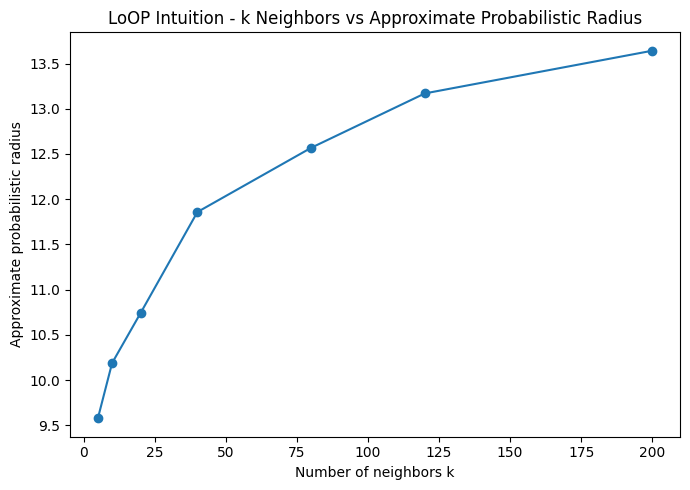

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\anomaly-detection-outlier-analysis\output\day04_pharma_loop_k_vs_radius.png


In [29]:
plt.figure(figsize=(7, 5))

plt.plot(
    loop_pharma_df["k_neighbors"],
    loop_pharma_df["approx_probabilistic_radius"],
    marker="o"
)

plt.title("LoOP Intuition - k Neighbors vs Approximate Probabilistic Radius")
plt.xlabel("Number of neighbors k")
plt.ylabel("Approximate probabilistic radius")

save_plot("day04_pharma_loop_k_vs_radius.png")

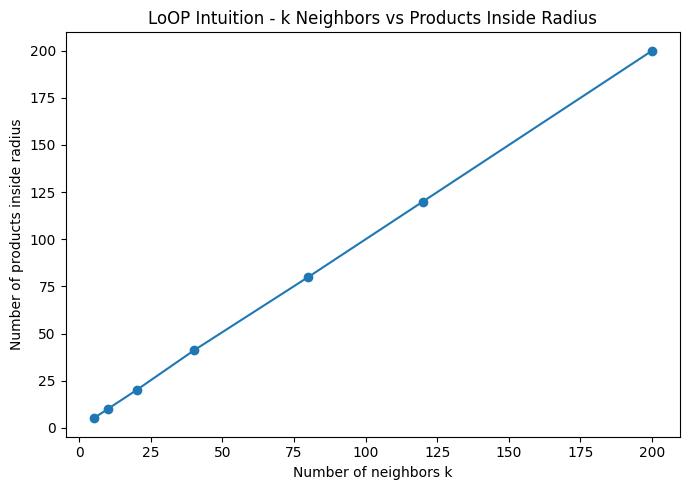

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\anomaly-detection-outlier-analysis\output\day04_pharma_loop_k_vs_products_inside_radius.png


In [30]:
plt.figure(figsize=(7, 5))

plt.plot(
    loop_pharma_df["k_neighbors"],
    loop_pharma_df["products_inside_radius"],
    marker="o"
)

plt.title("LoOP Intuition - k Neighbors vs Products Inside Radius")
plt.xlabel("Number of neighbors k")
plt.ylabel("Number of products inside radius")

save_plot("day04_pharma_loop_k_vs_products_inside_radius.png")